<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

In [ ]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

In [ ]:
# import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder
%cd '/content/drive/MyDrive/SDM'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SDM


In [ ]:
import pandas
import numpy
import matplotlib.pyplot as plt

# Notebook for Slide Set 5
## Tire Pricing Application


In [ ]:
# Import Tire_Pricing.xlsx
Tire_Pricing = pandas.read_excel("data/Tire_Pricing.xlsx")

In [ ]:
# Note: .transpose() transposes the summary
# statistics to a more compact form
Tire_Pricing.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Obs,61.0,31.000000,17.752934,1.00,16.00,31.00,46.00,61.00
Price,61.0,99.687541,23.533104,59.82,78.27,100.35,117.66,151.56
Diameter,61.0,15.540984,0.807749,14.00,15.00,16.00,16.00,17.00
Ratio,61.0,64.836066,7.301097,45.00,60.00,65.00,70.00,75.00
Tread,61.0,222.868852,20.503232,185.00,215.00,225.00,235.00,265.00
Weight,61.0,25.180328,5.609570,16.20,21.50,24.30,27.70,40.80
Terrain,61.0,0.131148,0.340363,0.00,0.00,0.00,0.00,1.00
Volume,61.0,254.229508,387.708584,5.00,49.00,120.00,288.00,2028.00
R,61.0,0.704918,0.459865,0.00,0.00,1.00,1.00,1.00
H,61.0,0.114754,0.321370,0.00,0.00,0.00,0.00,1.00


Following four histograms show the dependent variable, Price, and three independent variables, Diameter, Tread Width, and Volume. Note that Volume is skewed to the right. There are fewer sales of very high volumes than there are sales of lower volumes.

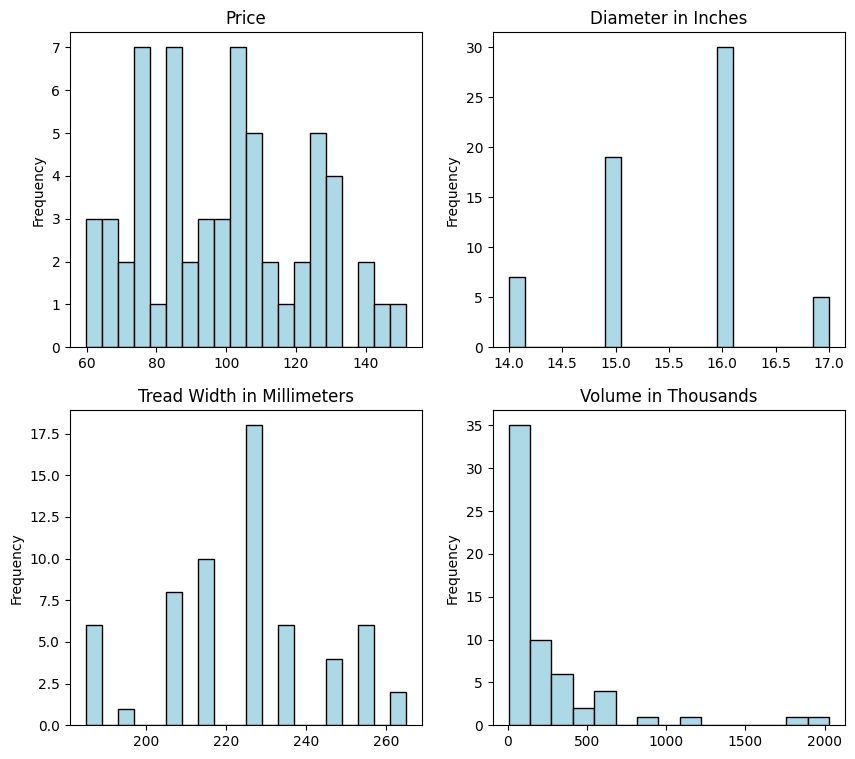

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2)
Tire_Pricing["Price"].plot.hist(
    ax=axes[0, 0],
    bins=20,
    title="Price",
    edgecolor="black",
    color="lightblue",
    figsize=(10, 9),
)
Tire_Pricing["Diameter"].plot.hist(
    ax=axes[0, 1],
    bins=20,
    title="Diameter in Inches",
    edgecolor="black",
    color="lightblue",
    figsize=(10, 9),
)
Tire_Pricing["Tread"].plot.hist(
    ax=axes[1, 0],
    bins=20,
    title="Tread Width in Millimeters",
    edgecolor="black",
    color="lightblue",
    figsize=(10, 9),
)
Tire_Pricing["Volume"].plot.hist(
    ax=axes[1, 1],
    bins=15,
    title="Volume in Thousands",
    edgecolor="black",
    color="lightblue",
    figsize=(10, 9),
)
plt.show()

In [ ]:
# Total volume of tires purchases
total_volume = Tire_Pricing["Volume"].sum()
total_volume

np.int64(15508)

In [ ]:
# Total expenditures on tire purchases
total_expenditures = Tire_Pricing[["Price", "Volume"]].product(axis=1).sum()
total_expenditures

np.float64(1409865.63)

In [ ]:
TireReg = tprstats.model("cs", "Price~Diameter+Ratio+Terrain+Weight+Tread+Volume+WW+OWL+H+V+Z", Tire_Pricing)
TireReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.918
No. Observations:                  61   F-statistic:                     106.2
Covariance Type:                  HC1   Prob (F-statistic):           2.99e-30
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -27.2056     52.689     -0.516      0.608    -133.089      78.678
Diameter       5.3728      2.780      1.933      0.059      -0.213      10.959
Ratio         -0.6184      0.271     -2.284      0.027      -1.163      -0.074
Terrain        8.9199      3.203      2.785      0.008       2.483      15.357
Weight         1.8909      0.627      3.018      0.004       0.632       3.150
Tread          0.1305      0.167      0.782      0.438      -0.205       0.466
Volume        -0.0033      0.002     -1.775      0.082      -0.007       0.000
WW             4.4036      2.738      1.608      0.114      -1.099       9.907
OWL            4.0631      3.127      1.299      0.200      -2.222      10.348
H              8.0769      2.412      3.348      0.002       3.229      12.924
V             23.8924      4.204      5.684      0.000      15.445      32.340
Z             26.3225      5.772      4.561      0.000      14.724      37.921
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 2.96e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
TireReg.scaled_coefficients()

,coefs,std_coefs,elasticities
Diameter,5.372826,0.184417,0.8376
Ratio,-0.618385,-0.191853,-0.4022
Terrain,8.919926,0.129010,0.0117
Weight,1.890898,0.450732,0.4776
Tread,0.130534,0.113728,0.2918
Volume,-0.003295,-0.054287,-0.0084
WW,4.403615,0.040800,0.0022
OWL,4.063062,0.069203,0.0080
H,8.076863,0.110298,0.0093
V,23.892381,0.304857,0.0236


### Some Diagnostics

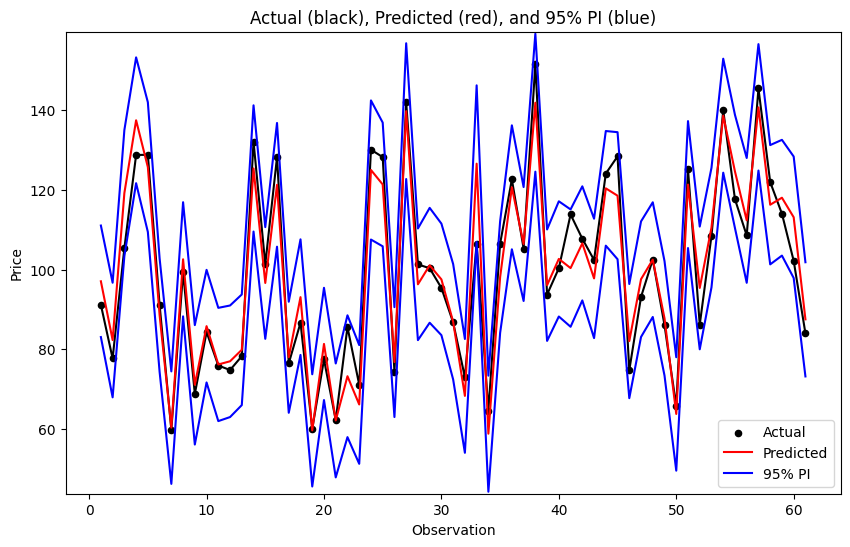

In [ ]:
# Plot actual and fitted values
# The function uses 95% prediction intervals
TireReg.plot_actual_fitted()

Investigate the residuals from the model.

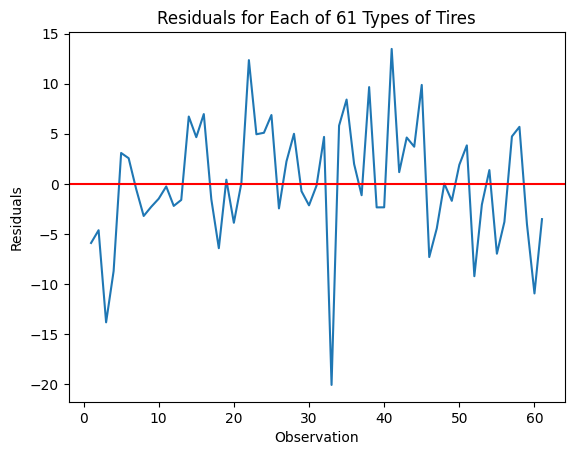

In [ ]:
# Extract residuals and name them resid
resids = TireReg.resid

plt.plot(Tire_Pricing["Obs"], resids)
plt.title("Residuals for Each of 61 Types of Tires")
plt.xlabel("Observation")
plt.ylabel("Residuals")
plt.axhline(0, color="red")

In [ ]:
# Find and view the index of the large negative residual
index = resids.argmin()
index

np.int64(32)

Note that index = 32, but the tire at index 32 is observation 33. This is because Python starts counting at 0.
Look at the Excel file and you will find that observation 33 is a Z tire.

In [ ]:
# Select all Z tires and view to see if there is anything unusual about this tire.
Ztires = Tire_Pricing.query("Z==1")
Ztires

,Obs,Price,Diameter,Ratio,Tread,Weight,Rating,Tirewall,Terrain,Volume,R,H,V,Z,BW,WW,OWL
4,5,128.82,16,60,215,24.0,Z,WW,0,27,0,0,0,1,0,1,0
23,24,130.11,16,55,225,23.6,Z,BW,0,16,0,0,0,1,1,0,0
26,27,142.02,17,45,245,24.1,Z,BW,0,120,0,0,0,1,1,0,0
32,33,106.53,16,50,215,23.5,Z,BW,0,20,0,0,0,1,1,0,0
37,38,151.56,17,45,245,25.1,Z,BW,0,50,0,0,0,1,1,0,0


### Predict Price of a Tire for Design Team
The design team in the company is anticipating using a tire with the following characteristics and Volume.

|  Characteristics  | |
| ------| -----|
| Diameter | 15 |
| Ratio | 65 |
| Terrain | 0 |
| Weight | 25 |
| Tread | 225 |
| WW | 0 |
| OWL | 0 |
| H | 0 |
| V | 0 |
| Z | 0 |
| Volume | 300 |

In [ ]:
Xnew = pandas.DataFrame({
        "Diameter": [15], "Ratio": [65], "Terrain": [0], "Weight": [25], "Tread": [225],  "WW": [0],
        "OWL": [0], "H": [0], "V": [0], "Z": [0], "Volume": [300],
    })
TireReg.prediction_intervals(Xnew, alpha=0.25)

,Predicted,Lower,Upper
0,88.845747,80.661586,97.029907


### Sensitivity Analysis
#### Model without Tread variable

In [ ]:
TireReg2 = tprstats.model(
    "cs", "Price~Diameter+Ratio+Terrain+Weight+Volume+WW+OWL+H+V+Z", Tire_Pricing
)
TireReg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.918
No. Observations:                  61   F-statistic:                     137.6
Covariance Type:                  HC1   Prob (F-statistic):           8.59e-33
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -16.2201     50.122     -0.324      0.748    -116.893      84.453
Diameter       6.0426      2.870      2.106      0.040       0.279      11.806
Ratio         -0.6488      0.267     -2.430      0.019      -1.185      -0.113
Terrain        8.9337      3.020      2.959      0.005       2.869      14.999
Weight         2.2655      0.442      5.130      0.000       1.378       3.153
Volume        -0.0029      0.002     -1.468      0.148      -0.007       0.001
WW             3.9265      2.348      1.673      0.101      -0.789       8.642
OWL            4.4716      2.749      1.626      0.110      -1.050       9.994
H              8.4229      2.616      3.219      0.002       3.168      13.678
V             23.7407      4.262      5.570      0.000      15.180      32.301
Z             26.8599      5.721      4.695      0.000      15.368      38.351
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 2.78e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
Xnew2 = pandas.DataFrame({
    "Diameter": [15], "Ratio": [65],"Terrain": [0], "Weight": [25], "WW": [0],
        "OWL": [0], "H": [0], "V": [0], "Z": [0], "Volume": [300]
})
TireReg2.prediction_intervals(Xnew2, alpha=0.25)

,Predicted,Lower,Upper
0,88.025207,79.862866,96.187548
